In [36]:
# mount the google drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [37]:
!pip install arch

In [38]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from arch import arch_model
from tensorflow.keras.layers import Bidirectional, LSTM, Dense, Dropout
from tensorflow.keras.models import Sequential
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [39]:
import tensorflow as tf
tf.random.set_seed(42)

In [40]:
# load the 2025 USEP dataset from Google Drive
filepath = "/content/drive/MyDrive/Singapore Forecasting Electricity Price/usep_data_2025.xlsx"
# read the Excel file into a pandas dataframe for preprocessing and modelling
usep_df = pd.read_excel(filepath)
# display the first 5 rows to verify the data structure and columns
usep_df.head()

,DATE,USEP,DEMAND,SOLAR
0,2025-01-01,93.600833,5930.052583,158.514792
1,2025-01-02,87.035833,6358.067917,162.426042
2,2025-01-03,105.036667,6407.756771,174.522083
3,2025-01-04,111.137083,6158.840583,177.016875
4,2025-01-05,99.658542,5989.193917,176.524375


# **ARIMA**

In [41]:
# create a stationary time series by calculating the first-order difference
usep_diff = usep_df['USEP'].diff().dropna()

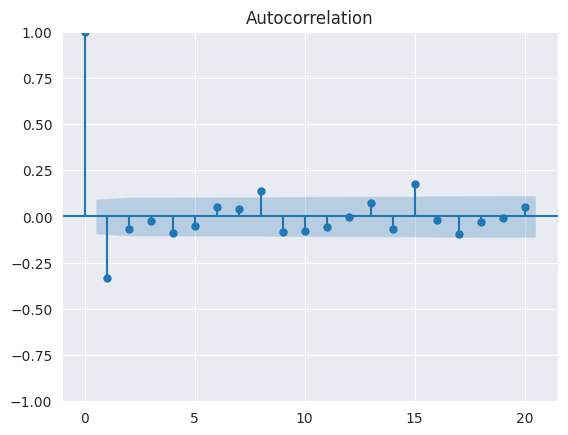

In [42]:
# plot the autocorrelation function (ACF) to identify the MA
sns.set_style("darkgrid")
plot_acf(usep_diff, lags = 20)
plt.show()

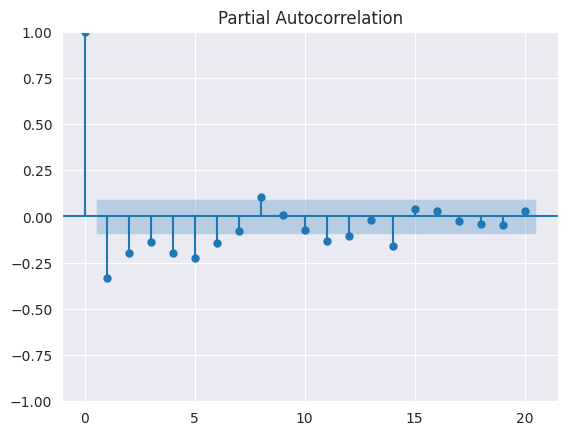

In [43]:
# plot the partial autocorrelation function (PACF) to identify AR
plot_pacf(usep_diff, lags = 20)
plt.show()

In [44]:
# initialize ARIMA model
arima_model = ARIMA(usep_df['USEP'], order = (1, 1, 1))
# fit the model parameters
arima_results = arima_model.fit()
# display the estimation summary
print(arima_results.summary())

                               SARIMAX Results                                
Dep. Variable:                   USEP   No. Observations:                  423
Model:                 ARIMA(1, 1, 1)   Log Likelihood               -2095.606
Date:                Mon, 25 May 2026   AIC                           4197.212
Time:                        04:25:00   BIC                           4209.347
Sample:                             0   HQIC                          4202.007
                                - 423                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.3888      0.039     10.069      0.000       0.313       0.465
ma.L1         -0.9181      0.022    -42.190      0.000      -0.961      -0.875
sigma2      1201.3733     23.491     51.142      0.0

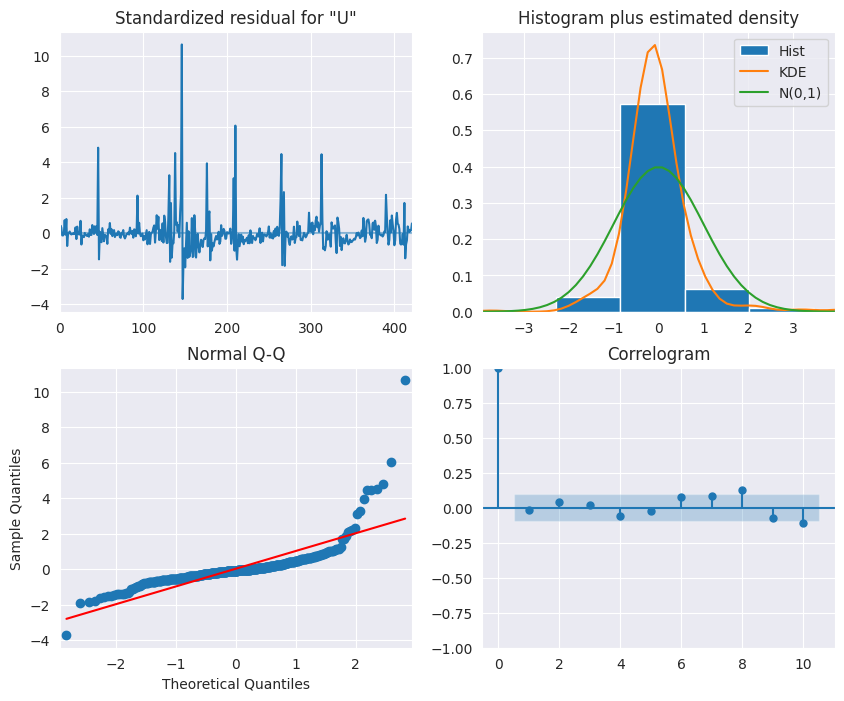

In [45]:
# generate diagnostic plots for the fitted ARIMA model
arima_results.plot_diagnostics(figsize = (10, 8))
plt.show()

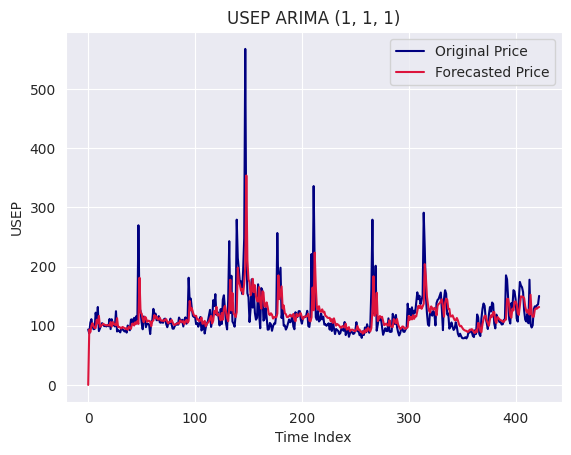

In [46]:
# plot the actual USEP and the forecasted USEP based on ARIMA model
forecast = arima_results.predict(start = usep_df.index[0], end = usep_df.index[-1])
plt.plot(usep_df['USEP'], color = "navy", label = "Original Price")
plt.plot(forecast, color = "crimson", label = "Forecasted Price")
plt.title("USEP ARIMA (1, 1, 1)")
plt.xlabel("Time Index")
plt.ylabel("USEP")
plt.legend()
plt.show()

# **GARCH**

In [47]:
# extract the raw residuals from the fitted ARIMA model
residuals = arima_results.resid

In [48]:
# initialize the GARCH model to analyze the volatility
garch_model = arch_model(residuals, p = 1, q = 1, vol = "GARCH", dist = "t")
# fit the GARCH model parameters to the residuals
garch_results = garch_model.fit(disp = 0)
# print the parameter estimations
print(garch_results.summary())

                        Constant Mean - GARCH Model Results                         
Dep. Variable:                         None   R-squared:                       0.000
Mean Model:                   Constant Mean   Adj. R-squared:                  0.000
Vol Model:                            GARCH   Log-Likelihood:               -1857.75
Distribution:      Standardized Student's t   AIC:                           3725.51
Method:                  Maximum Likelihood   BIC:                           3745.74
                                              No. Observations:                  423
Date:                      Mon, May 25 2026   Df Residuals:                      422
Time:                              04:25:01   Df Model:                            1
                               Mean Model                               
                 coef    std err          t      P>|t|  95.0% Conf. Int.
------------------------------------------------------------------------
mu            -3

# **Feature Engineering**

In [49]:
# create a new feature by shifting the ARIMA residuals backward by one time step
usep_df['lag1'] = usep_df['USEP'].shift(1)

In [50]:
usep_df['arima_residuals_lag1'] = residuals.shift(1)

In [51]:
# create a new feature by extracting the garch residuals
usep_df['garch_residual'] = garch_results.resid

In [52]:
# create a new feature by calculating the standardized residuals from the GARCH model
usep_df['garch_std_resid'] = garch_results.resid/ garch_results.conditional_volatility

In [53]:
# drop all rows containing missing values (NaNs)
usep_df = usep_df.dropna()
usep_df.head()

,DATE,USEP,DEMAND,SOLAR,lag1,arima_residuals_lag1,garch_residual,garch_std_resid
1,2025-01-02,87.035833,6358.067917,162.426042,93.600833,93.600833,-2.975886,-0.037788
2,2025-01-03,105.036667,6407.756771,174.522083,87.035833,-6.519986,19.596264,0.387499
3,2025-01-04,111.137083,6158.840583,177.016875,105.036667,16.052163,14.834499,0.402655
4,2025-01-05,99.658542,5989.193917,176.524375,111.137083,11.290398,-1.259385,-0.044884
5,2025-01-06,94.180833,6446.642542,176.036458,99.658542,-4.803486,-1.453464,-0.070010


In [54]:
# compute the pairwise pearson correlation coefficients for all numerical columns.
usep_df.corr(method = "spearman")

,DATE,USEP,DEMAND,SOLAR,lag1,arima_residuals_lag1,garch_residual,garch_std_resid
DATE,1.000000,0.070640,0.103216,0.418540,0.069047,-0.024640,-0.012412,-0.040243
USEP,0.070640,1.000000,0.540707,0.028812,0.685872,0.328700,0.578880,0.611230
DEMAND,0.103216,0.540707,1.000000,-0.051947,0.405253,0.177026,0.223944,0.240115
SOLAR,0.418540,0.028812,-0.051947,1.000000,0.075969,0.007806,0.002070,-0.008009
lag1,0.069047,0.685872,0.405253,0.075969,1.000000,0.569461,0.017546,0.023949
arima_residuals_lag1,-0.024640,0.328700,0.177026,0.007806,0.569461,1.000000,0.211965,0.203074
garch_residual,-0.012412,0.578880,0.223944,0.002070,0.017546,0.211965,1.000000,0.968750
garch_std_resid,-0.040243,0.611230,0.240115,-0.008009,0.023949,0.203074,0.968750,1.000000


In [55]:
# drop the irrelevant columns
usep_df = usep_df.drop(columns = ['DATE', 'DEMAND', 'SOLAR'])
usep_df.head()

,USEP,lag1,arima_residuals_lag1,garch_residual,garch_std_resid
1,87.035833,93.600833,93.600833,-2.975886,-0.037788
2,105.036667,87.035833,-6.519986,19.596264,0.387499
3,111.137083,105.036667,16.052163,14.834499,0.402655
4,99.658542,111.137083,11.290398,-1.259385,-0.044884
5,94.180833,99.658542,-4.803486,-1.453464,-0.070010


# **Data Splitting**

In [56]:
# separate the features from the target
X = usep_df.drop(columns = ['USEP'])
y = usep_df['USEP']

In [57]:
# split the features into training and testing sets
X_train, X_test = X.iloc[:366], X.iloc[366:]
y_train, y_test = y.iloc[:366], y.iloc[366:]

In [58]:
X_train_reshaped = np.expand_dims(X_train, axis = 1)
X_test_reshaped = np.expand_dims(X_test, axis = 1)

# **Model Training**

In [59]:
model = Sequential()
model.add(Bidirectional(LSTM(128, kernel_regularizer = "l2", activation = "tanh", return_sequences = True), input_shape = (1, 4)))
model.add(LSTM(32, kernel_regularizer = "l2", activation = "tanh"))
model.add(Dense(32, activation = "relu"))
model.add(Dense(8, activation = "relu"))
model.add(Dense(1))
model.compile(optimizer = "adam", loss = "mse", metrics = ['mse'])


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [60]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional_1 (Bidirectional) │ (None, 1, 256)         │       136,192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 32)             │        36,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 8)              │           264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 174,513 (681.69 KB)

 Trainable params: 174,513 (681.69 KB)

 Non-trainable params: 0 (0.00 B)

In [61]:
history = model.fit(X_train_reshaped, y_train,
                    epochs = 100,
                    batch_size = 16,
                    validation_split = 0.1,
                    verbose = 1)

Epoch 1/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 8s 49ms/step - loss: 15855.7314 - mse: 15854.0605 - val_loss: 10327.9834 - val_mse: 10326.4902
Epoch 2/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 15430.2432 - mse: 15428.8174 - val_loss: 9742.5234 - val_mse: 9741.1230
Epoch 3/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 14553.7646 - mse: 14552.3086 - val_loss: 8904.1201 - val_mse: 8902.5840
Epoch 4/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 13469.1289 - mse: 13467.5215 - val_loss: 7913.3301 - val_mse: 7911.6562
Epoch 5/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 12129.0420 - mse: 12127.3242 - val_loss: 6681.7124 - val_mse: 6679.9546
Epoch 6/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 10486.7490 - mse: 10484.9629 - val_loss: 5249.8921 - val_mse: 5248.0786
Epoch 7/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 8469.5596 - mse: 8467.7256 - val_loss: 3445.2771 - val_mse: 3443.4226
Epoch 8/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 6075.8921 - mse:

# **Model Evaluation**

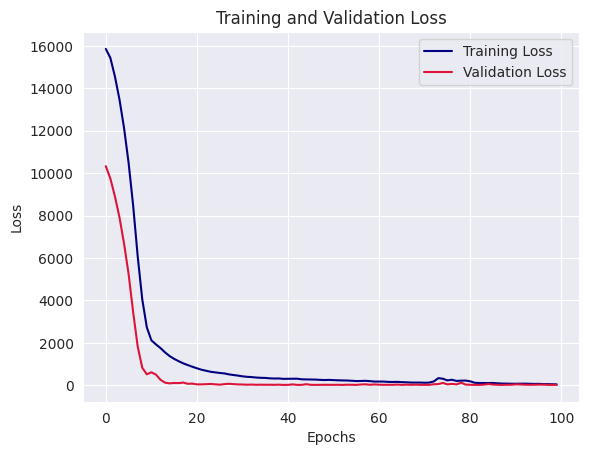

In [62]:
plt.plot(history.history['loss'], label = 'Training Loss', color = "navy")
plt.plot(history.history['val_loss'], label = 'Validation Loss', color = "crimson")
plt.title("Training and Validation Loss")
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

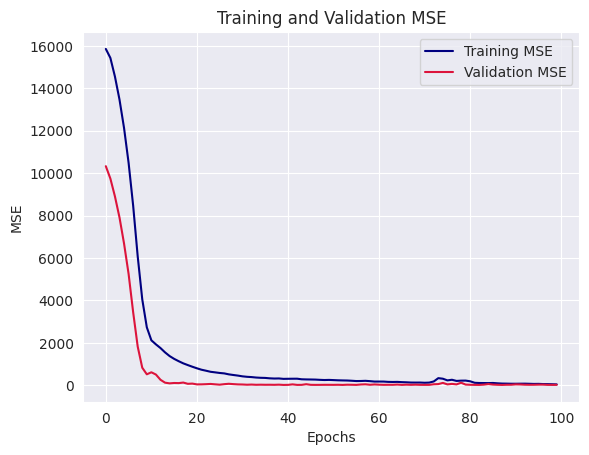

In [63]:
plt.plot(history.history['mse'], label = 'Training MSE', color = "navy")
plt.plot(history.history['val_mse'], label = 'Validation MSE', color = "crimson")
plt.title("Training and Validation MSE")
plt.xlabel('Epochs')
plt.ylabel('MSE')
plt.legend()
plt.show()

In [64]:
# use the optimized refitted random forest model to predict the price for the training set and testing set
y_pred_train = model.predict(X_train_reshaped)
y_pred_test = model.predict(X_test_reshaped)

12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step


In [65]:
# compute the evaluation for the training set
mae_train = mean_absolute_error(y_train, y_pred_train)
mse_train = mean_squared_error(y_train, y_pred_train)
r2_train = r2_score(y_train, y_pred_train)

In [66]:
# compute the evaluation for the testing set
mae_test = mean_absolute_error(y_test, y_pred_test)
mse_test = mean_squared_error(y_test, y_pred_test)
r2_test = r2_score(y_test, y_pred_test)

In [67]:
# display the evaluation results for the training set
print("Mean Absolute Error (MAE): {:.4f}".format(mae_train))
print("Root Mean Squared Error (MSE): {:.4f}".format(np.sqrt(mse_train)))
print("R-squared (R2) Score: {:.4f}".format(r2_train))

Mean Absolute Error (MAE): 3.3856
Root Mean Squared Error (MSE): 6.0383
R-squared (R2) Score: 0.9796


In [68]:
# display the evaluation results for the testing set
print("Mean Absolute Error (MAE): {:.4f}".format(mae_test))
print("Root Mean Squared Error (MSE): {:.4f}".format(np.sqrt(mse_test)))
print("R-squared (R2) Score: {:.4f}".format(r2_test))

Mean Absolute Error (MAE): 4.3167
Root Mean Squared Error (MSE): 5.3526
R-squared (R2) Score: 0.9510


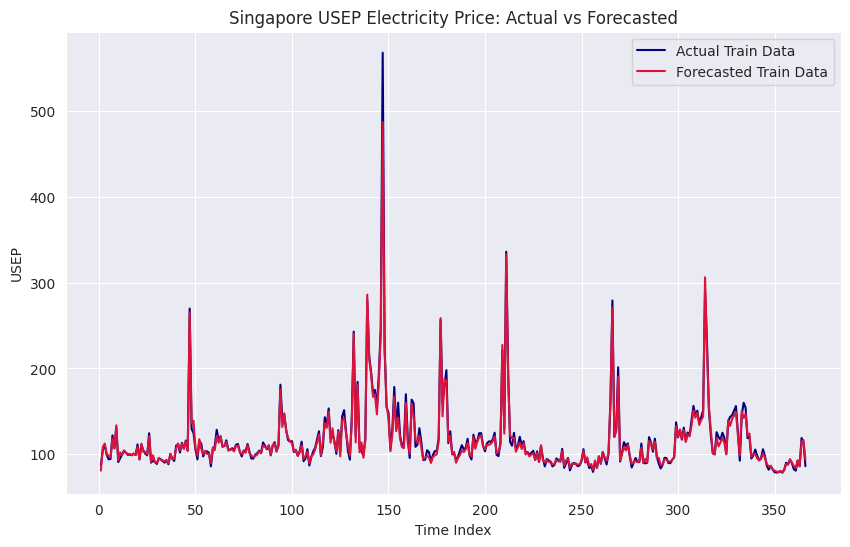

In [69]:
# convert the raw training numpy array predictions into a pandas Series
y_pred_train_series = pd.Series(y_pred_train.flatten(), index = y_train.index)

# plot the actual vs forecasted USEP electricity price based on training set
plt.figure(figsize = (10, 6))
sns.set_style("darkgrid")
plt.plot(y_train.index,
         y_train.values, color = "navy", label = "Actual Train Data")
plt.plot(y_pred_train_series.index,
         y_pred_train_series.values, color = "crimson", label = "Forecasted Train Data")
plt.title("Singapore USEP Electricity Price: Actual vs Forecasted")
plt.xlabel("Time Index")
plt.ylabel("USEP")
plt.legend()
plt.show()

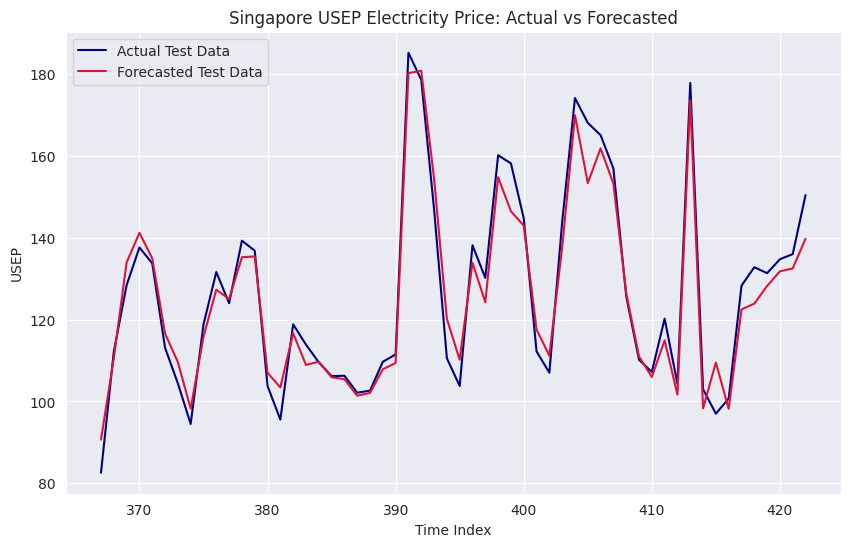

In [70]:
# convert the raw testing numpy array predictions into a pandas Series
y_pred_test_series = pd.Series(y_pred_test.flatten(), index = y_test.index)

# plot the actual vs forecasted USEP electricity price based on testing set
plt.figure(figsize = (10, 6))
sns.set_style("darkgrid")
plt.plot(y_test.index,
         y_test.values, color = "navy", label = "Actual Test Data")
plt.plot(y_pred_test_series.index,
         y_pred_test_series.values, color = "crimson", label = "Forecasted Test Data")
plt.title("Singapore USEP Electricity Price: Actual vs Forecasted")
plt.xlabel("Time Index")
plt.ylabel("USEP")
plt.legend()
plt.show()